In [1]:
import math

import torch

a = 7

b = [1, 4, 7, 6, 9, 2]

print(b.index(a))


2


In [2]:
a = torch.Tensor([7])

b = torch.Tensor([1, 4, 7, 6, 9, 2])

d = 1 / (a - b + 1)

print(d)
print(d.argmax())

tensor([ 0.1429,  0.2500,  1.0000,  0.5000, -1.0000,  0.1667])
tensor(2)


In [3]:
import matplotlib.pyplot as plt

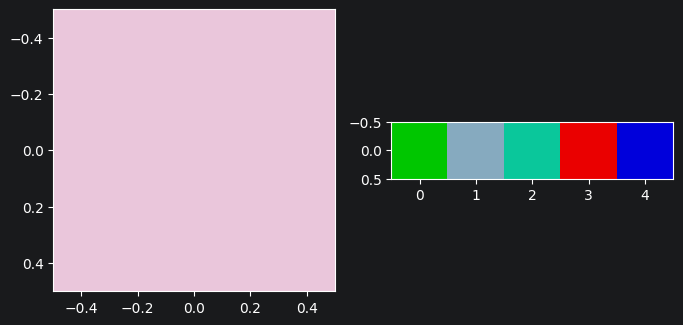

In [4]:
c1 = torch.rand(1, 1, 3)
c2 = torch.rand(1, 2, 3)

def split_rgb(t):
    r = torch.zeros_like(t)
    g = torch.zeros_like(t)
    b = torch.zeros_like(t)
    r[:, :, 0] = t[:, :, 0]
    g[:, :, 1] = t[:, :, 1]
    b[:, :, 2] = t[:, :, 2]
    return r, g, b

c2 = torch.cat([c2, *split_rgb(c1)], dim=1)
c2 = c2[:, torch.randperm(c2.shape[1]), :]
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(c1)
ax[1].imshow(c2)

plt.show()

In [5]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

def build_color_dataset(n, s=5):

    c1 = torch.rand(n, 1, 3)
    c2 = torch.rand(n, s-3, 3)

    sp = split_rgb(c1)
    fcs = torch.cat([c2, *sp], dim=1)
    fcs = fcs[:, torch.randperm(fcs.shape[1]), :]
    return TensorDataset(c1, fcs)

In [6]:
dataset = build_color_dataset(200)


In [7]:

# join heads in a single weight
import torch.nn as nn

h1 = nn.Linear(3, 3)
h2 = nn.Linear(3, 3)
h3 = nn.Linear(3, 3)

q1 = h1(c1)
q2 = h2(c1)
q3 = h3(c1)

print(q1)
print(q2)
print(q3)

a1 = q1 @ c2.permute(0, 2, 1)
a2 = q2 @ c2.permute(0, 2, 1)
a3 = q3 @ c2.permute(0, 2, 1)

sr = c2[:, a1.argmax(), :]
sg = c2[:, a2.argmax(), :]
sb = c2[:, a3.argmax(), :]

print(a1.argmax(), a2.argmax(), a3.argmax())
rc = sr + sg + sb

print(rc)

tensor([[[-0.6663,  0.1964, -0.0551]]], grad_fn=<ViewBackward0>)
tensor([[[0.8098, 0.7178, 0.4381]]], grad_fn=<ViewBackward0>)
tensor([[[-0.5733,  0.8854,  0.6399]]], grad_fn=<ViewBackward0>)
tensor(0) tensor(1) tensor(2)
tensor([[0.5711, 2.2284, 1.3601]])


In [8]:
class MHA(nn.Module):
    def __init__(self):
        super(MHA, self).__init__()
        self.q = nn.Linear(3, 9)


    def forward(self, x, y, at=False):
        q = self.q(x)
        hq = torch.unflatten(q, 2, (-1, 3)).permute(0, 2, 1, 3)
        hy = y.unsqueeze(-2).permute(0, 2, 1, 3)

        a = 1 / (torch.sum(torch.pow(hy - hq, 2), dim=-1) + 0.1)
        # no derivative for argmax, use soft argmax instead (softmax)
        a = torch.softmax(a, dim=-1)
        o = a.unsqueeze(-1) * y.unsqueeze(1)
        out = torch.sum(o, dim=-2) / torch.sum(a, dim=-1, keepdim=True)
        if not at:
            return torch.sum(out, dim=1, keepdim=True)
        else:
            return torch.sum(out, dim=1, keepdim=True), a




  0%|          | 0/100000 [00:00<?, ?it/s]

6.0198226146028555e-05


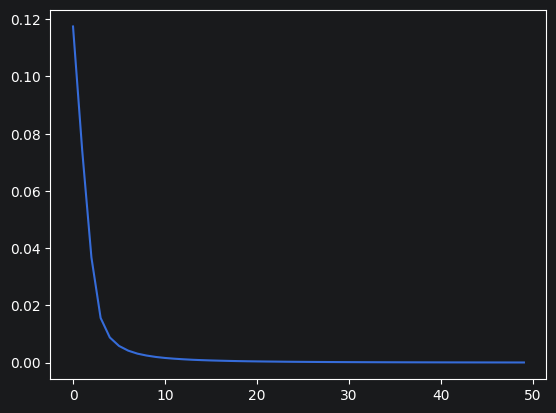

In [9]:
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm.auto import tqdm

def train(model, data, epochs=10, lr=0.001, batch_size=16):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    progress = tqdm(total=len(data) * epochs)
    lh = []
    for epoch in range(epochs):
        el = []
        for (x, y) in DataLoader(data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, y)
            loss = crit(out, x)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])
        lh.append(sum(el) / len(el))

    progress.close()
    return lh





mha = MHA()
dataset = build_color_dataset(2000)
lh = train(mha, dataset, epochs=50, lr=0.001, batch_size=32)
print(lh[-1])
plt.plot(lh)
plt.show()

In [10]:
c1, c2 = dataset[0]
print(c1)
print(mha(c1.unsqueeze(0), c2.unsqueeze(0)))

tensor([[0.8523, 0.7972, 0.8830]])
tensor([[[0.8520, 0.8089, 0.9156]]], grad_fn=<SumBackward1>)


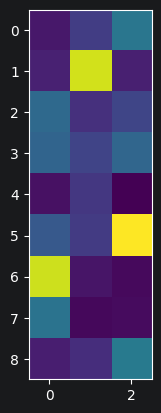

In [11]:
plt.imshow(mha.q.weight.data)
plt.show()

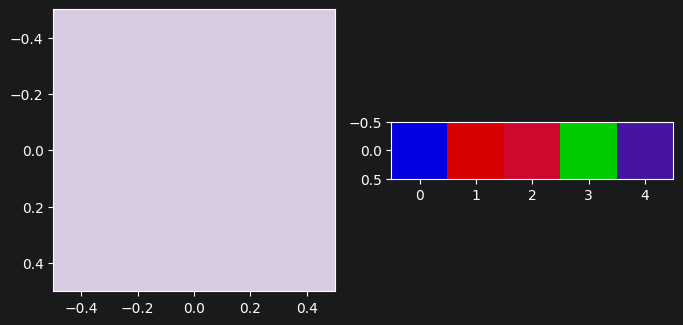

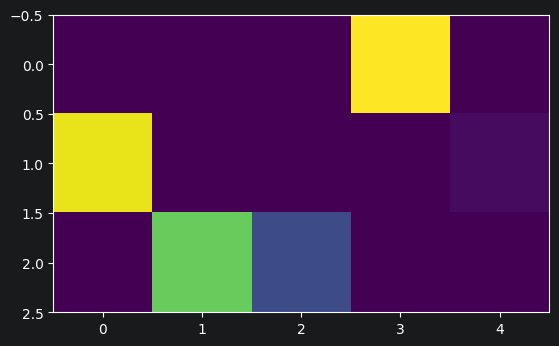

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(c1.unsqueeze(0))
ax[1].imshow(c2.unsqueeze(0))
plt.show()

o, a = mha(c1.unsqueeze(0), c2.unsqueeze(0), at=True)

plt.imshow(a.detach().squeeze(0))
plt.show()

In [13]:
class MHA(nn.Module):
    def __init__(self):
        super(MHA, self).__init__()
        self.q = nn.Linear(3, 3, bias=False)

    def forward(self, x, y, at=False):
        q = self.q(x)
        hq = torch.unflatten(q, 2, (-1, 1)).permute(0, 2, 1, 3)
        hy = torch.unflatten(y, 2, (-1, 1)).permute(0, 2, 1, 3)
        a = 1 / (torch.sum(torch.pow(hy - hq, 2), dim=-1) + 0.01)
        a = torch.softmax(a, dim=-1)
        o = a.unsqueeze(-1) * hy
        out = torch.sum(o, dim=-2, keepdim=True) / torch.sum(a.unsqueeze(-1), dim=-2, keepdim=True)
        out = out.permute(0, 2, 1, 3).flatten(2)
        if not at:
            return out
        else:
            return out, a


mha = MHA()

for (x, y) in DataLoader(dataset, batch_size=1, shuffle=True):

    print(x.shape, mha(x, y).shape)
    break

torch.Size([1, 1, 3]) torch.Size([1, 1, 3])


  0%|          | 0/400000 [00:00<?, ?it/s]

0.06577152273957691


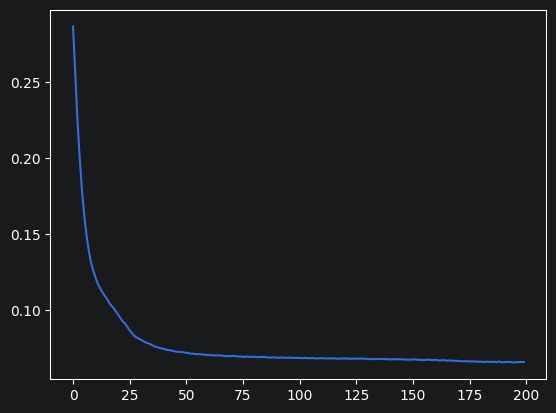

In [14]:
mha = MHA()
lh = train(mha, dataset, epochs=200, lr=0.001, batch_size=32)
print(lh[-1])
plt.plot(lh)
plt.show()

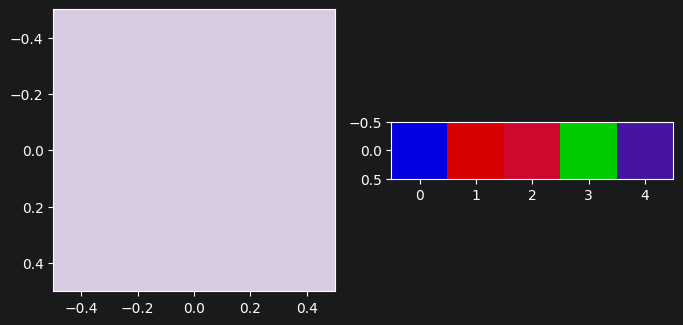

tensor([[0.8523, 0.7972, 0.8830]])
tensor([[[0.3871, 0.7972, 0.3362]]], grad_fn=<ViewBackward0>)


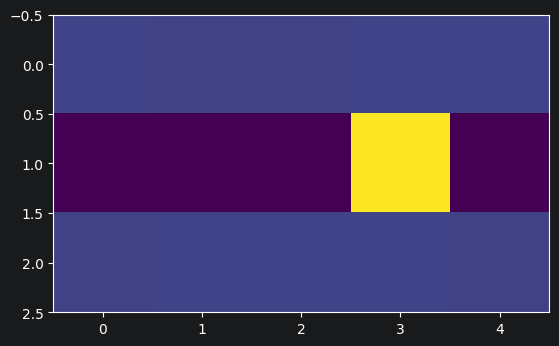

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(c1.unsqueeze(0))
ax[1].imshow(c2.unsqueeze(0))
plt.show()

o, a = mha(c1.unsqueeze(0), c2.unsqueeze(0), at=True)
print(c1)
print(o)
plt.imshow(a.detach().squeeze(0))
plt.show()

In [16]:
wi = {
    'S': 0,
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'X': 5,
    'Y': 6,
    'E': 7,
    '-': 8
}

In [17]:
import random

In [18]:
def gen_seq():

    fs = ['S']
    for _ in range(random.randint(4, 10)):
        fs.append(random.choice('abcd'))

    f1 = random.randint(1, len(fs)-2)
    f2 = random.randint(f1, len(fs)-1)

    rc1 = random.choice('XY')
    rc2 = random.choice('XY')

    fs[f1] = rc1
    fs[f2] = rc2

    fs.append('E')

    r = {
        'XX': 0,
        'XY': 1,
        'YX': 2,
        'YY': 3
    }
    return ''.join(fs), r[rc1 + rc2]

s, q = gen_seq()
print(s, q)

SbbYXdE 2


In [19]:
class MHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(MHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, at=False):
        q = self.q(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        k = self.k(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 3, 1)

        a = q @ k
        a /= math.sqrt(self.n_dim)
        # todo apply padding mask
        a = torch.softmax(a, dim=-1)

        v = self.v(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        o = a @ v
        o = o.permute(0, 2, 1, 3).flatten(2)
        if not at:
            return self.o(o)
        else:
            return self.o(o), a

emb = nn.Embedding(9, 4)
mha = MHA(n_dim=4, heads=2)

q1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
q2 = torch.LongTensor([wi[c] for c in 'SaYbXcE'])

e1 = emb(q1).unsqueeze(0)
e2 = emb(q2).unsqueeze(0)

o1 = mha(e1)
o2 = mha(e2)

print(torch.isclose(o1[:, -1], o2[:, -1]).all())

tensor(True)


In [20]:
emb = nn.Embedding(9, 4)
q1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
print(torch.arange(1, q1.shape[0]).unsqueeze(0).repeat(4, 1))

tensor([[1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6]])


In [21]:
def binary(x, bits):
    mask = 2**torch.arange(bits-1,-1,-1).to(x.device, x.dtype)
    return x.unsqueeze(-1).bitwise_and(mask).ne(0).float()

e = emb(q1)
be = binary(torch.arange(1, e.shape[0] + 1), 4)
enc = e + be
print(enc)

tensor([[ 0.9980, -1.2790, -0.8480,  2.2294],
        [-0.1007, -1.4454,  1.1456, -1.6469],
        [ 0.7819,  0.9749,  1.1271, -0.4297],
        [-2.3140,  2.2887, -0.6088, -0.0701],
        [-0.8057,  1.9354, -0.2389, -0.5911],
        [ 1.4554, -0.0366,  2.1520,  0.6865],
        [ 1.9758,  3.6230,  0.9204,  0.6898]], grad_fn=<AddBackward0>)


In [22]:
emb = nn.Embedding(9, 4)
mha = MHA(n_dim=4, heads=2)

q1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
q2 = torch.LongTensor([wi[c] for c in 'SaYbXcE'])

be = binary(torch.arange(1, len(q1) + 1), 4)

e1 = emb(q1).unsqueeze(0) + be
e2 = emb(q2).unsqueeze(0) + be

o1 = mha(e1 )
o2 = mha(e2 )


print(torch.isclose(o1[:, -1], o2[:, -1]).all())

tensor(False)


In [23]:
def seq_data(n):

    seqs = []
    labels = []
    for _ in range(n):
        s, q = gen_seq()
        seqs.append(s)
        labels.append(q)

    seqs = [[wi[c] for c in s] for s in seqs]
    ml = max([len(s) for s in seqs])
    em = torch.LongTensor([len(s) - 1 for s in seqs])
    seqs = [q + [wi['-']] * (ml - len(q)) for q in seqs]
    return TensorDataset(torch.LongTensor(seqs), em, torch.LongTensor(labels))

dataset = seq_data(500)

In [24]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.mha = MHA(n_dim, n_head)
        self.lm = nn.Sequential(
            nn.Linear(n_dim, 4),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

    def forward(self, x):
        pos = binary(torch.arange(1, x.shape[1] + 1), self.n_dim)
        e = self.emb(x) + pos
        mha = self.mha(e)
        return self.lm(mha)

  0%|          | 0/50000 [00:00<?, ?it/s]

0.28514343220740557


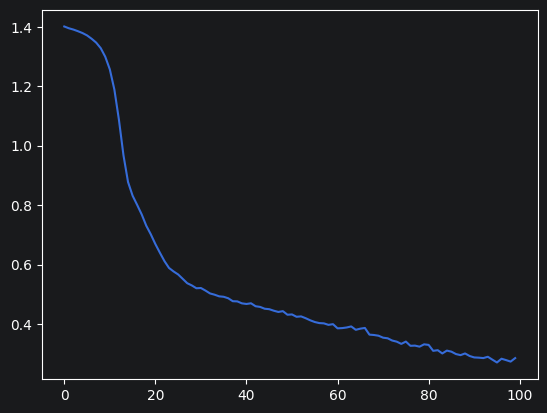

In [25]:
def train_model(model, data, epochs=10, lr=0.001, batch_size=16):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()
    progress = tqdm(total=len(data) * epochs)
    lh = []
    for epoch in range(epochs):
        el = []
        for (x, em, y) in DataLoader(data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x)
            loss = crit(out[torch.arange(x.shape[0]), em], y)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])
        lh.append(sum(el) / len(el))

    progress.close()
    return lh

model = Model(vocab_size=9, n_dim=8, n_head=2)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
print(lh[-1])
plt.plot(lh)
plt.show()

In [26]:
q1 = torch.LongTensor([[wi[c] for c in 'SaXbYcE']])
q2 = torch.LongTensor([[wi[c] for c in 'SaYbXcE']])

model.eval()
with torch.no_grad():
    o1 = model(q1)
    o2 = model(q2)

r = {
    'XX': 0,
    'XY': 1,
    'YX': 2,
    'YY': 3
}

print(o1[:, -1].argmax())
print(o2[:, -1].argmax())


tensor(2)
tensor(2)


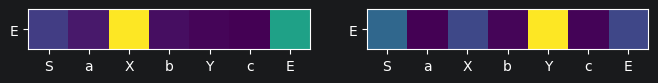

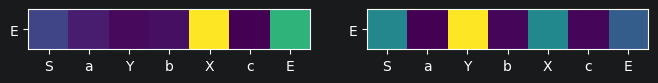

In [27]:
def plot_at(at, ticks):
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))

    ax[0].imshow(at[0, -1, :].unsqueeze(0))

    ax[0].set_xticks(range(len(ticks)))
    ax[0].set_xticklabels(ticks)
    ax[0].set_yticks([0])
    ax[0].set_yticklabels(['E'])
    ax[1].imshow(at[1, -1, :].unsqueeze(0))
    ax[1].set_xticks(range(len(ticks)))
    ax[1].set_xticklabels(ticks)
    ax[1].set_yticks([0])
    ax[1].set_yticklabels(['E'])
    plt.show()

pos = binary(torch.arange(1, q1.shape[1] + 1), model.n_dim)

with torch.no_grad():
    e1 = model.emb(q1) + pos
    o, a1 = model.mha(e1, at=True)

    e2 = model.emb(q2) + pos
    o, a2 = model.mha(e2, at=True)

at1 = a1.squeeze(0)
at2 = a2.squeeze(0)

ticks1 = 'SaXbYcE'
ticks2 = 'SaYbXcE'

plot_at(at1, ticks1)
plot_at(at2, ticks2)


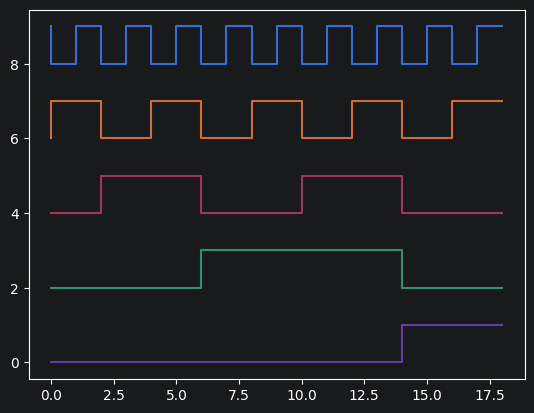

In [28]:
be = binary(torch.arange(1, 20), 5)
be = be + torch.arange(5).unsqueeze(0) * 2
for s in torch.flip(be, dims=[1]).T:
    plt.step(torch.arange(s.shape[0]), s)
plt.show()

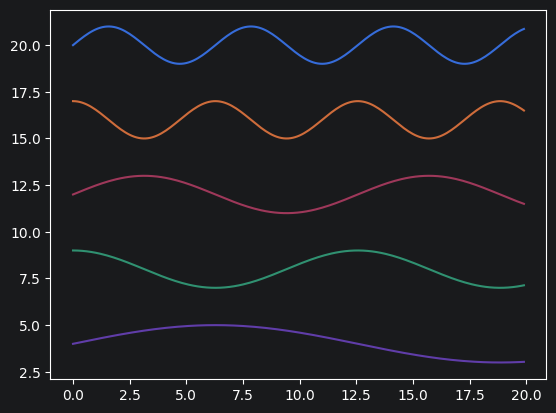

In [29]:
x = torch.arange(0, 20, 0.1)

for i in range(5):

    if i % 2 == 0:
        t = x / (2 ** (2 * i / 4))
        st = torch.sin(t)
    else:
        t = x / (2 ** (2 * (i - 1) / 4))
        st = torch.cos(t)

    plt.plot(x, (5 - i) * 4 + st)
plt.show()

In [30]:
def pos_encode(max_len, d_model, base=10000.0):
    position = torch.arange(max_len).unsqueeze(1)

    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(base) / d_model))

    pe = torch.zeros(max_len, d_model)

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe



  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

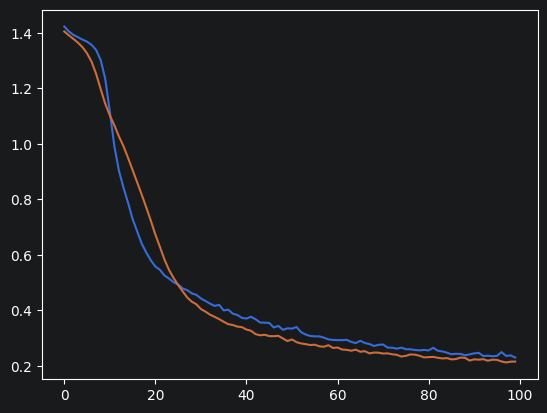

In [31]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, use_pos=True, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.mha = MHA(n_dim, n_head)
        self.lm = nn.Sequential(
            nn.Linear(n_dim, 4),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim
        self.pos = nn.Parameter(pos_encode(max_len, n_dim, base=2), requires_grad=False)
        self.use_pos = use_pos

    def forward(self, x):
        if not self.use_pos:
            pos = binary(torch.arange(1, x.shape[1] + 1), self.n_dim)
        else:
            pos = self.pos[:x.shape[1], :]
        e = self.emb(x) + pos
        mha = self.mha(e)
        return self.lm(mha)


model = Model(vocab_size=9, n_dim=8, n_head=2, use_pos=False)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
plt.plot(lh)
model = Model(vocab_size=9, n_dim=8, n_head=2, use_pos=True)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
plt.plot(lh)
plt.show()


In [32]:
wi = {
    'S': 0,
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'A': 5,
    'B': 6,
    'C': 7,
    'D': 8,
    'X': 9,
    'Y': 10,
    'E': 11,
    '-': 12,
    '^': 13
}

In [97]:
def gen_up_seq(n=15):
    r = ''
    for _ in range(random.randint(1, (n - 3) // 2)):
        r += random.choice('abcdABCD')

    return f'S{r}^{r.upper()}E'

def gen_up_data(n, l=15):
    seqs = []
    for _ in range(n):
        s = gen_up_seq(l)
        seqs.append(s)

    lm = [[0] * s.index('^') + [1] * (len(s) - s.index('^') - 1) + [0] for s in seqs]
    seqs = [[wi[c] for c in s] for s in seqs]
    ml = max([len(s) for s in seqs])
    am = [[1] * len(s) + [0] * (ml - len(s)) for s in seqs]
    lm = [s + [0] * (ml - len(s)) for s in lm]
    seqs = [q + [wi['-']] * (ml - len(q)) for q in seqs]
    return TensorDataset(torch.LongTensor(seqs), torch.Tensor(am), torch.Tensor(lm))

data = gen_up_data(500, 10)
test = gen_up_data(50, 20)



In [124]:
class MHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(MHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, m=None, at=False):
        q = self.q(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        k = self.k(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 3, 1)

        a = q @ k
        a /= math.sqrt(self.n_dim)

        if m is not None:
            pm = torch.logical_not(m).unsqueeze(1).repeat(1, a.shape[-1], 1).unsqueeze(1)
            cm = torch.triu(torch.ones(a.shape[-2], a.shape[-1]), diagonal=1).unsqueeze(0).unsqueeze(0)
            fm = torch.logical_or(pm, cm)
        else:
            fm = torch.triu(torch.ones(a.shape[-2], a.shape[-1]), diagonal=1).bool()

        a = torch.masked_fill(a, fm, -1e6)
        a = torch.softmax(a, dim=-1)

        v = self.v(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        o = a @ v
        o = o.permute(0, 2, 1, 3).flatten(2)
        if not at:
            return self.o(o)
        else:
            return self.o(o), a


# mha = MHA(n_dim=4, heads=2)
# emb = nn.Embedding(len(wi), 4)
# q1 = torch.LongTensor([wi[c] for c in 'SaXb'])
#
# mha(emb(q1).unsqueeze(0), torch.Tensor([[1, 1, 0, 0]])).shape

In [127]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.mha = MHA(n_dim, n_head)
        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim
        self.pos = nn.Parameter(pos_encode(max_len, n_dim, base=2), requires_grad=False)

    def forward(self, x, m=None):
        pos = self.pos[:x.shape[1], :]
        e = self.emb(x) + pos
        mha = self.mha(e, m)
        return self.lm(mha)

  0%|          | 0/50000 [00:00<?, ?it/s]

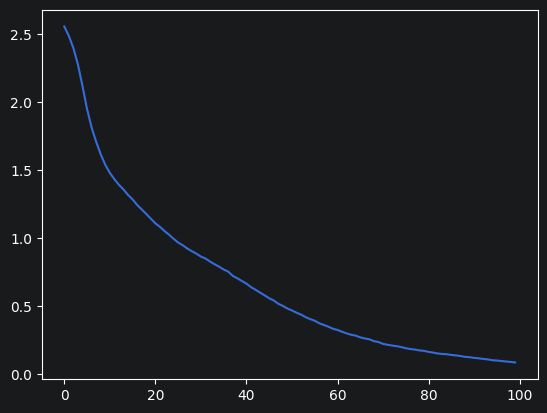

In [141]:
def lm_train(model, data_train, data_test=None, epochs=100, lr=0.001, batch_size=32):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss(reduction='none')
    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for epoch in range(epochs):
        el = []
        for (x, m, lm) in DataLoader(data_train, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, m)
            loss = crit(torch.flatten(out[:, :-1], start_dim=0, end_dim=1), x[:, 1:].flatten())
            loss = torch.sum(loss * lm[:, :-1].flatten()) / torch.sum(lm)

            loss.backward()
            el.append(loss.item())
            optimizer.step()
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    return lh


model = Model(vocab_size=len(wi), n_dim=8, n_head=2, max_len=20)
lh = lm_train(model, data, epochs=100, lr=0.001, batch_size=32)
plt.plot(lh)
plt.show()